In [8]:
library(astsa)
data(UnempRate)

library(forecast)
library(ggplot2)

n <- length(UnempRate)
h <- 12

treino <- head(UnempRate, n-h)
teste  <- tail(UnempRate, h)

# conferir
frequency(treino)
start(treino)
end(treino)

[1] 12

[1] 1948    1

[1] 2015   11

$index
integer(0)

$replacements
numeric(0)

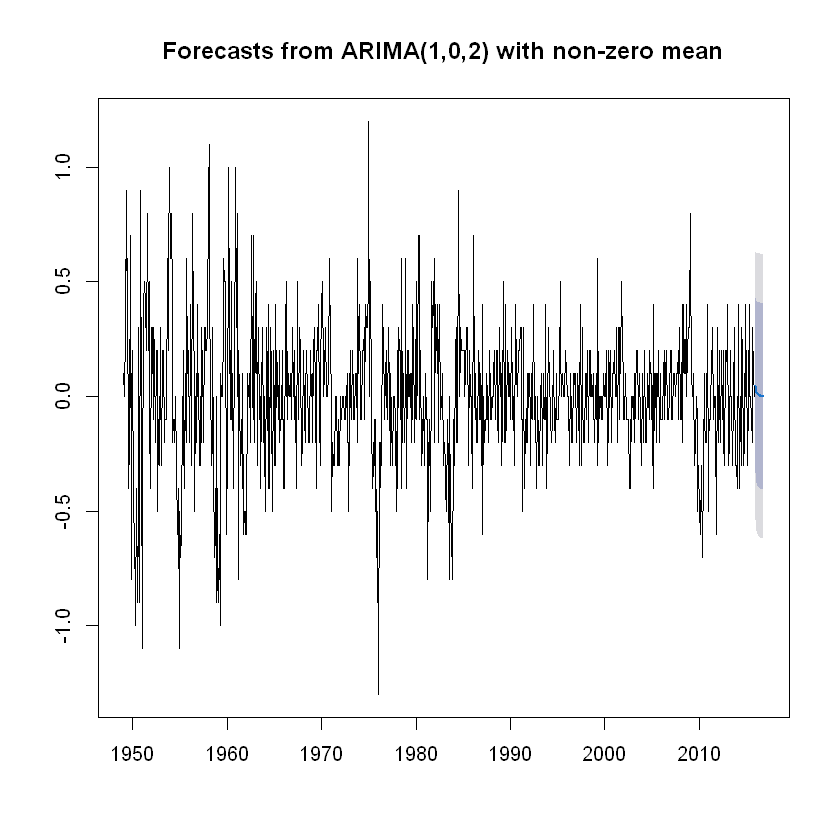

In [9]:
library(tseries)
serie_diff <- diff(treino)
serie_diff12 <- diff(serie_diff, 12)

library(forecast)
tsoutliers(treino)

#ajuste <- auto.arima(serie_diff12)
ajuste <- Arima(
  serie_diff12,
  order = c(1,0,2)
)

prev <- forecast(ajuste, h = 12)
plot(prev)

In [10]:
modelo_arima <- Arima(
  treino,
  order = c(1,1,2),
  seasonal = list(
    order = c(0,1,0),
    period = 12
  )
)

In [11]:
prev_arima <- forecast(
  modelo_arima,
  h = h,
  level = c(80,95)
)

#print(prev_arima)

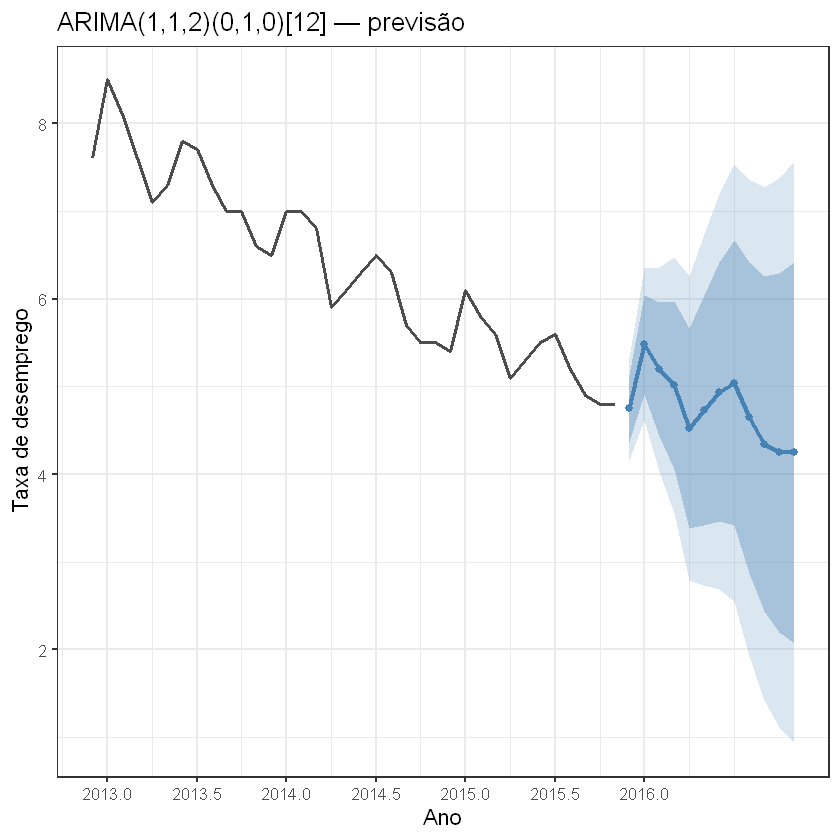

In [12]:
n_hist_graf <- 36

serie_zoom <- tail(treino, n_hist_graf)


df_hist_z <- data.frame(
  t = time(serie_zoom),
  y = as.numeric(serie_zoom)
)


df_prev_a <- data.frame(
  t = time(prev_arima$mean),
  mean = as.numeric(prev_arima$mean),
  lo80 = as.numeric(prev_arima$lower[, "80%"]),
  hi80 = as.numeric(prev_arima$upper[, "80%"]),
  lo95 = as.numeric(prev_arima$lower[, "95%"]),
  hi95 = as.numeric(prev_arima$upper[, "95%"])
)


ggplot() +
  geom_line(
    data=df_hist_z,
    aes(t,y),
    colour="gray30",
    size=0.9
  ) +
  geom_ribbon(
    data=df_prev_a,
    aes(t,ymin=lo95,ymax=hi95),
    fill = "steelblue",
    alpha=0.20
  ) +
  geom_ribbon(
    data=df_prev_a,
    aes(t,ymin=lo80,ymax=hi80),
    fill = "steelblue",
    alpha=0.35
  ) +
  geom_line(
    data=df_prev_a,
    aes(t,mean),
    colour = "steelblue",
    size=1.2
  ) +
  geom_point(
    data=df_prev_a,
    aes(t,mean),
    colour = "steelblue",
    size=2
  ) +
  scale_x_continuous(
    breaks = pretty(df_hist_z$t, n=6)
  ) +
  ggtitle("ARIMA(1,1,2)(0,1,0)[12] — previsão") +
  xlab("Ano") +
  ylab("Taxa de desemprego") +
  theme_bw(base_size=13)

In [13]:
erro <- as.numeric(teste) - as.numeric(prev_arima$mean)


MAE <- mean(abs(erro))

RMSE <- sqrt(mean(erro^2))

MAPE <- mean(abs(erro / as.numeric(teste))) * 100


metricas <- data.frame(
  MAE = MAE,
  RMSE = RMSE,
  MAPE = MAPE
)

round(metricas,4)

MAE,RMSE,MAPE
<dbl>,<dbl>,<dbl>
0.1958,0.2436,4.0669


In [ ]:
# Holt-Winters aditivo
h_prev <- 12  # horizonte: 12 meses à frente
hw_add  <- hw(treino, seasonal = "additive",       h = h_prev, level = c(80, 95))
# Holt-Winters multiplicativo
hw_mult <- hw(treino, seasonal = "multiplicative", h = h_prev, level = c(80, 95))

cat("=== Holt-Winters Aditivo ===\n")
print(summary(hw_add$model))

cat("\n=== Holt-Winters Multiplicativo ===\n")
print(summary(hw_mult$model))

cat("\nAIC Aditivo       :", round(hw_add$model$aic,  2), "\n")
cat("AIC Multiplicativo :", round(hw_mult$model$aic, 2), "\n")

# Seleciona o melhor
if (hw_add$model$aic <= hw_mult$model$aic) {
  modelo_hw <- hw_add
  tipo_hw   <- "Aditivo"
} else {
  modelo_hw <- hw_mult
  tipo_hw   <- "Multiplicativo"
}
cat("\n→ Modelo selecionado: Holt-Winters", tipo_hw, "\n")

=== Holt-Winters Aditivo ===
Holt-Winters' additive method 

Call:
hw(y = treino, h = h_prev, seasonal = "additive", level = c(80, 
    95))

  Smoothing parameters:
    alpha = 0.862 
    beta  = 1e-04 
    gamma = 0.1379 

  Initial states:
    l = 2.9312 
    b = -0.0057 
    s = -0.3279 -0.6 -0.8446 -0.6393 -0.0452 -0.1438
           0.2465 -0.108 -0.013 0.4742 1.1187 0.8822

  sigma:  0.2702

     AIC     AICc      BIC 
3347.764 3348.532 3427.718 

Training set error measures:
                      ME      RMSE       MAE       MPE    MAPE      MASE
Training set 0.008957943 0.2675069 0.2030486 0.1199722 3.75812 0.2294189
                  ACF1
Training set 0.3086566

=== Holt-Winters Multiplicativo ===
Holt-Winters' multiplicative method 

Call:
hw(y = treino, h = h_prev, seasonal = "multiplicative", level = c(80, 
    95))

  Smoothing parameters:
    alpha = 0.7275 
    beta  = 0.0063 
    gamma = 0.2718 

  Initial states:
    l = 3.0374 
    b = -0.1097 
    s = 0.9106 0.7899 0

In [16]:
# Parâmetros estimados do modelo selecionado
par_hw <- modelo_hw$model$par
cat("Parâmetros Holt-Winters", tipo_hw, ":\n")
cat("  alpha (nível)     =", round(par_hw["alpha"], 4), "\n")
cat("  beta  (tendência) =", round(par_hw["beta"],  4), "\n")
cat("  gamma (sazonal)   =", round(par_hw["gamma"], 4), "\n")

Parâmetros Holt-Winters Aditivo :
  alpha (nível)     = 0.862 
  beta  (tendência) = 1e-04 
  gamma (sazonal)   = 0.1379 



	Ljung-Box test

data:  Residuals from Holt-Winters' additive method
Q* = 238.09, df = 24, p-value < 2.2e-16

Model df: 0.   Total lags used: 24



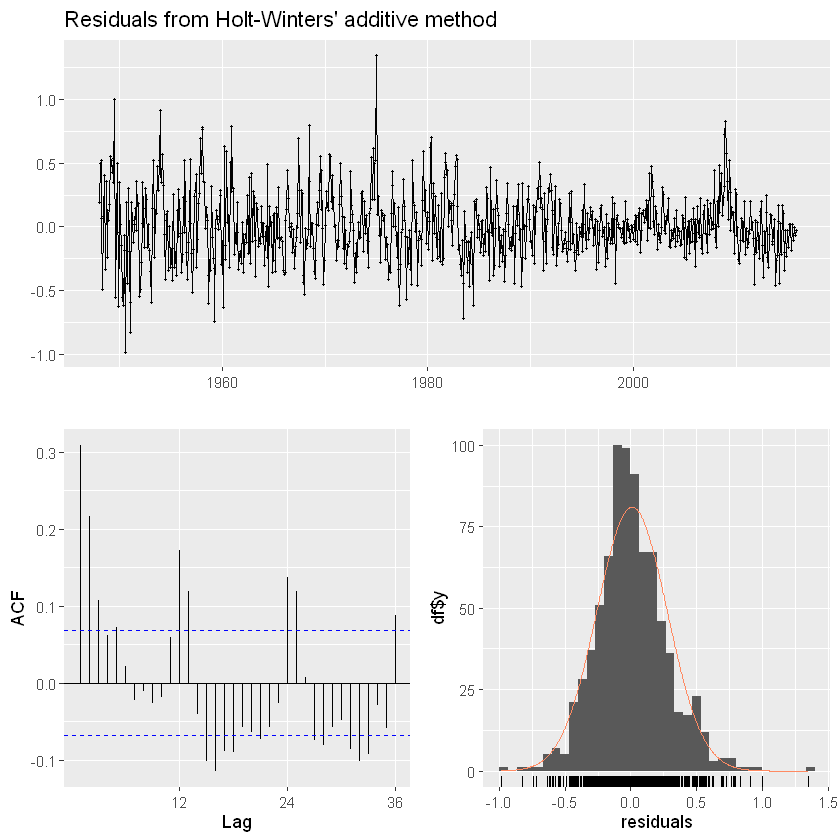

In [18]:
checkresiduals(modelo_hw)

=== Previsões Holt-Winters Aditivo ===
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 2015       4.903212 4.556972 5.249451 4.373684 5.432739
Jan 2016       5.626526 5.169383 6.083669 4.927387 6.325666
Feb 2016       5.465461 4.919478 6.011445 4.630451 6.300471
Mar 2016       5.250692 4.628408 5.872976 4.298991 6.202393
Apr 2016       4.731893 4.041677 5.422108 3.676300 5.787486
May 2016       4.911937 4.159888 5.663986 3.761777 6.062097
Jun 2016       5.270970 4.461786 6.080154 4.033430 6.508511
Jul 2016       5.353423 4.490868 6.215978 4.034259 6.672587
Aug 2016       5.046274 4.133452 5.959096 3.650233 6.442314
Sep 2016       4.751975 3.791503 5.712448 3.283059 6.220891
Oct 2016       4.712618 3.706740 5.718497 3.174260 6.250977
Nov 2016       4.739819 3.690488 5.789151 3.135005 6.344633


Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


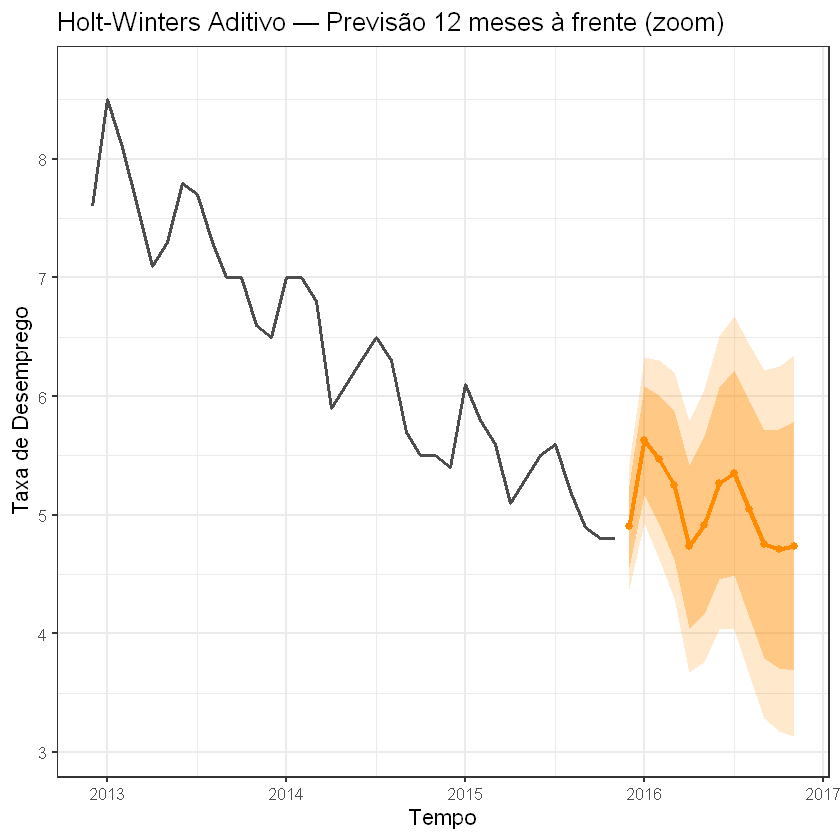

In [17]:
cat("=== Previsões Holt-Winters", tipo_hw, "===\n")
print(modelo_hw)

# ── Gráfico focado na previsão ──────────────────────────────────────────────
df_prev_hw <- data.frame(
  t    = as.numeric(time(modelo_hw$mean)),
  mean = as.numeric(modelo_hw$mean),
  lo80 = as.numeric(modelo_hw$lower[, "80%"]),
  hi80 = as.numeric(modelo_hw$upper[, "80%"]),
  lo95 = as.numeric(modelo_hw$lower[, "95%"]),
  hi95 = as.numeric(modelo_hw$upper[, "95%"])
)

y_min_hw <- min(df_hist_z$y, df_prev_hw$lo95) * 0.98
y_max_hw <- max(df_hist_z$y, df_prev_hw$hi95) * 1.02

ggplot() +
  geom_line(data = df_hist_z, aes(x = t, y = y),
            colour = "gray30", size = 0.9) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "darkorange", alpha = 0.20) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo80, ymax = hi80),
              fill = "darkorange", alpha = 0.35) +
  geom_line(data = df_prev_hw, aes(x = t, y = mean),
            colour = "darkorange", size = 1.2) +
  geom_point(data = df_prev_hw, aes(x = t, y = mean),
             colour = "darkorange", size = 2) +
  coord_cartesian(ylim = c(y_min_hw, y_max_hw)) +
  ggtitle(paste0("Holt-Winters ", tipo_hw, " — Previsão 12 meses à frente (zoom)")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw(base_size = 13)

In [25]:
print(modelo_hw$mean)

          Jan      Feb      Mar      Apr      May      Jun      Jul      Aug
2015                                                                        
2016 5.626526 5.465461 5.250692 4.731893 4.911937 5.270970 5.353423 5.046274
          Sep      Oct      Nov      Dec
2015                            4.903212
2016 4.751975 4.712618 4.739819         


In [29]:
accuracy(prev_arima)
accuracy(modelo_hw)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,-0.001016251,0.2953556,0.2240442,0.1012057,4.137763,0.2531412,0.0002358624


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,0.008957943,0.2675069,0.2030486,0.1199722,3.75812,0.2294189,0.3086566


In [27]:
erro <- as.numeric(teste) - as.numeric(prev_arima$mean)


MAE <- mean(abs(erro))

RMSE <- sqrt(mean(erro^2))

MAPE <- mean(abs(erro / as.numeric(teste))) * 100


metricas <- data.frame(
  MAE = MAE,
  RMSE = RMSE,
  MAPE = MAPE
)

round(metricas,4)

MAE,RMSE,MAPE
<dbl>,<dbl>,<dbl>
0.1958,0.2436,4.0669


In [26]:
erro <- as.numeric(teste) - as.numeric(modelo_hw$mean)


MAE <- mean(abs(erro))

RMSE <- sqrt(mean(erro^2))

MAPE <- mean(abs(erro / as.numeric(teste))) * 100


metricas <- data.frame(
  MAE = MAE,
  RMSE = RMSE,
  MAPE = MAPE
)

round(metricas,4)

MAE,RMSE,MAPE
<dbl>,<dbl>,<dbl>
0.1801,0.2226,3.7036


In [31]:
df_real <- data.frame(
  t = as.numeric(time(teste)),
  y = as.numeric(teste)
)

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


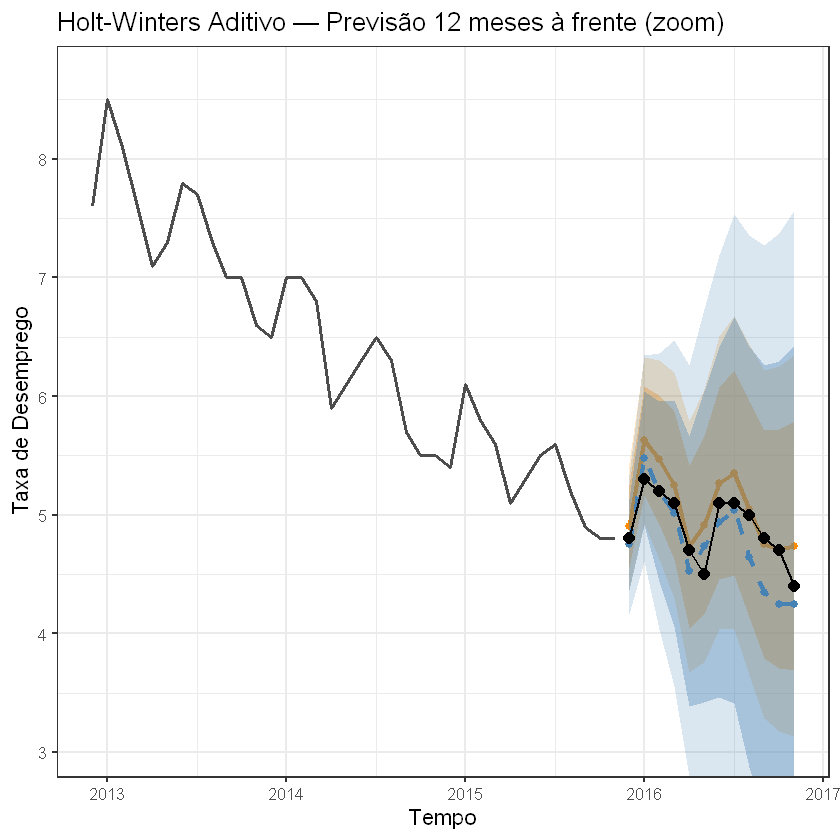

In [34]:
ggplot() +
  geom_line(data = df_hist_z, aes(x = t, y = y),
            colour = "gray30", size = 0.9) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "darkorange", alpha = 0.20) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo80, ymax = hi80),
              fill = "darkorange", alpha = 0.35) +
  geom_line(data = df_prev_hw, aes(x = t, y = mean),
            colour = "darkorange", size = 1.2) +
  geom_point(data = df_prev_hw, aes(x = t, y = mean),
             colour = "darkorange", size = 2) +
  geom_line(
      data=df_hist_z,
      aes(t,y),
      colour="gray30",
      size=0.9
    ) +
    geom_ribbon(
      data=df_prev_a,
      aes(t,ymin=lo95,ymax=hi95),
      fill = "steelblue",
      alpha=0.20
    ) +
    geom_ribbon(
      data=df_prev_a,
      aes(t,ymin=lo80,ymax=hi80),
      fill = "steelblue",
      alpha=0.35
    ) +
    geom_line(
      data=df_prev_a,
      aes(t,mean),
      colour = "steelblue",
      size=1.2,
      linetype = "dashed"
    ) +
    geom_point(
      data=df_prev_a,
      aes(t,mean),
      colour = "steelblue",
      size=2
    ) +
    geom_point(data = df_real, aes(x = t, y = y),
            colour = "black", size = 3, shape = 16) +
    geom_line(data  = df_real, aes(x = t, y = y),
    colour = "black", size = 0.8) +             
  coord_cartesian(ylim = c(y_min_hw, y_max_hw)) +
  ggtitle(paste0("Holt-Winters ", tipo_hw, " — Previsão 12 meses à frente (zoom)")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw(base_size = 13)